In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#load the dataset
df = pd.read_csv(r"position_salary.csv",encoding="latin1")  
print(df.head()) 
print(df.info()) 

                            Position   Location  Gender    Education  \
0  QNXT Configuration QA/Testing SME  Ghaziabad  Female  B.Tech/B.E.   
1           Provider Data Management  New Delhi  Female  B.Tech/B.E.   
2          Accessibility Engineer QA      Noida  Female          BCA   
3           Senior Software Engineer  Jalandhar    Male          NaN   
4         Java Developer/Spring Boot     Meerut    Male          B.A   

   Experience (Years)   Salary  
0                  11  2014510  
1                  24  1624349  
2                  25  1926223  
3                  27  2403560  
4                  11  1128404  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3467 entries, 0 to 3466
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Position            3448 non-null   object
 1   Location            3467 non-null   object
 2   Gender              3443 non-null   object
 3   Education         

In [3]:
# Encoding categorical variables
df = pd.get_dummies(df, columns=['Position', 'Location', 'Gender', 'Education'], drop_first=True)

# Handle missing values
df.fillna(df.mean(), inplace=True)

# Extracting numerical features
features = ['Experience (Years)', 'Salary']  # Add encoded categorical columns if needed
X = df[features]

# Standardizing data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA(n_components=2)  # Reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51666731 0.48333269]


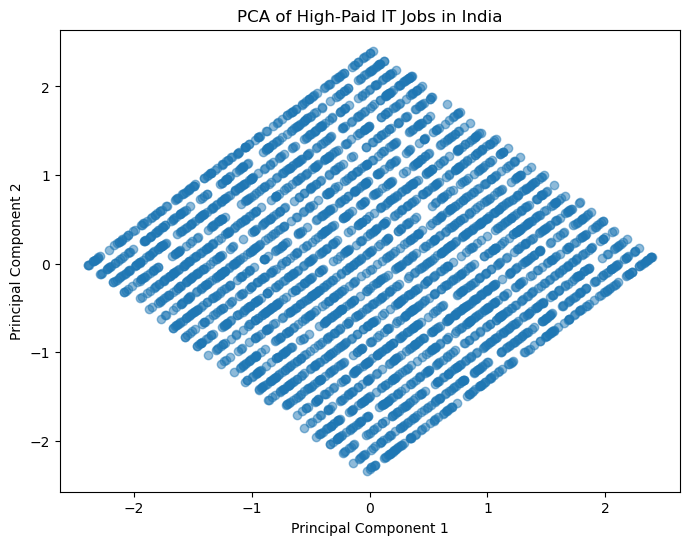

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of High-Paid IT Jobs in India")
plt.show()